Install SHAP and Joblib libraries required for explainable AIInstall SHAP

In [25]:
!pip install -q shap joblib

Mount Google Drive so the notebook can access the dataset and trained model

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Search Google Drive recursively for CSV datasets and PKL model files

In [27]:
import os
import glob

print("CSV files:")
for f in glob.glob(
    "/content/drive/MyDrive/**/*.csv",
    recursive=True
):
    print(f)

print("\nPKL files:")
for f in glob.glob(
    "/content/drive/MyDrive/**/*.pkl",
    recursive=True
):
    print(f)

CSV files:
/content/drive/MyDrive/contacts (1).csv
/content/drive/MyDrive/contacts.csv
/content/drive/MyDrive/mathamathics for computing/iris.csv
/content/drive/MyDrive/mathamathics for computing/GPA.csv
/content/drive/MyDrive/mathamathics for computing/olympics.csv
/content/drive/MyDrive/mathamathics for computing/entire_dataframe.csv
/content/drive/MyDrive/mathamathics for computing/extracted_data.csv
/content/drive/MyDrive/mathamathics for computing/complete_olympic_data.csv
/content/drive/MyDrive/mathamathics for computing/selected_olympic_data.csv
/content/drive/MyDrive/smartcare -ai/xai/smartcare_final_preprocessed_dataset.csv
/content/drive/MyDrive/xai/xai_results/shap_feature_importance.csv

PKL files:
/content/drive/MyDrive/smartcare -ai/xai/best_model.pkl


Define the paths to the preprocessed dataset and trained machine-learning model

In [28]:
DATA_PATH = "/content/drive/MyDrive/smartcare -ai/xai/smartcare_final_preprocessed_dataset.csv"

MODEL_PATH = "/content/drive/MyDrive/smartcare -ai/xai/best_model.pkl"

print("Dataset exists:", os.path.exists(DATA_PATH))
print("Model exists:", os.path.exists(MODEL_PATH))

Dataset exists: True
Model exists: True


load the data set and model

In [29]:
import pandas as pd
import joblib

df = pd.read_csv(DATA_PATH)

best_model = joblib.load(MODEL_PATH)

print("Dataset:", df.shape)
print("Model:", best_model)

print("\nFeatures:")
print(df.drop(columns=["no_show"]).columns.tolist())

Dataset: (800, 45)
Model: LogisticRegression(max_iter=1000, random_state=42)

Features:
['numerical__age', 'numerical__waiting_days', 'numerical__previous_appointments', 'numerical__missed_previous_appointments', 'numerical__previous_missed_rate', 'numerical__has_previous_appointment', 'numerical__appointment_month', 'numerical__appointment_dayofweek', 'numerical__systolic_bp', 'numerical__diastolic_bp', 'numerical__blood_sugar_mg_dl', 'numerical__cholesterol_mg_dl', 'numerical__bmi', 'categorical__gender_Female', 'categorical__gender_Male', 'categorical__blood_group_A+', 'categorical__blood_group_A-', 'categorical__blood_group_AB+', 'categorical__blood_group_AB-', 'categorical__blood_group_B+', 'categorical__blood_group_B-', 'categorical__blood_group_O+', 'categorical__blood_group_O-', 'categorical__department_Cardiology', 'categorical__department_General Medicine', 'categorical__department_Laboratory Services', 'categorical__department_Neurology', 'categorical__department_Orthopedics

Verify the model

In [30]:
X = df.drop(columns=["no_show"])
y = df["no_show"]

print("X shape:", X.shape)
print("y shape:", y.shape)

if hasattr(best_model, "n_features_in_"):
    print("Model expects:", best_model.n_features_in_)
    print("Dataset has:", X.shape[1])

    if best_model.n_features_in_ == X.shape[1]:
        print(" Feature count matches!")
    else:
        print(" Feature count DOES NOT match!")

X shape: (800, 44)
y shape: (800,)
Model expects: 44
Dataset has: 44
 Feature count matches!


Calculate SHAP values using a LinearExplainer to determine how each feature contributes to the model's predictions.

In [31]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

explainer = shap.LinearExplainer(
    best_model,
    X
)

shap_values = explainer(X)

print("SHAP values calculated!")
print("Shape:", shap_values.values.shape)

SHAP values calculated!
Shape: (800, 44)


Generate a global SHAP beeswarm plot to visualize the importance and impact of the top 20 features on the model's predictions.

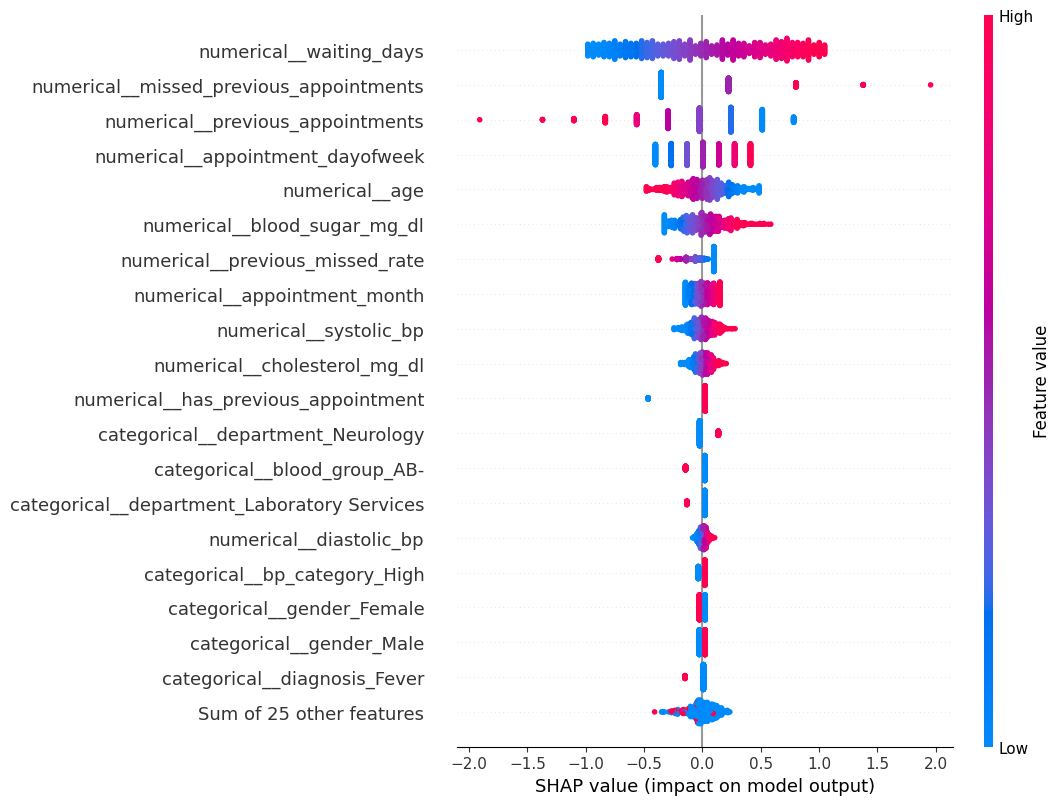

In [32]:
shap.plots.beeswarm(
    shap_values,
    max_display=20
)

Generate a SHAP bar plot to rank the top 20 features according to their overall importance in the model's predictions.

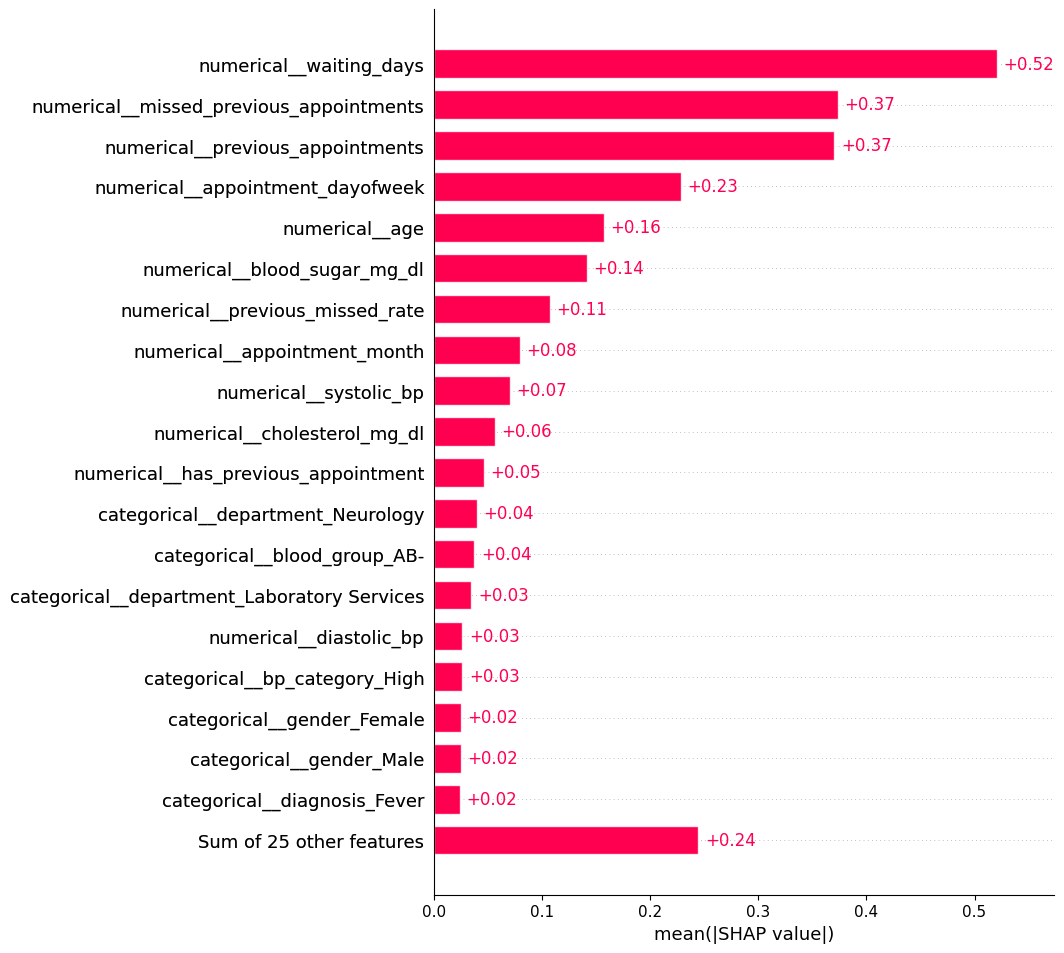

In [33]:
shap.plots.bar(
    shap_values,
    max_display=20
)

Calculate the mean absolute SHAP value for each feature, rank the features by their overall importance, assign a rank number, and display the top 20 most influential features in a table.

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Mean_Absolute_SHAP":
        np.abs(shap_values.values).mean(axis=0)
})

importance = (
    importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

importance["Rank"] = importance.index + 1

importance = importance[
    [
        "Rank",
        "Feature",
        "Mean_Absolute_SHAP"
    ]
]

display(importance.head(20))

,Rank,Feature,Mean_Absolute_SHAP
0,1,numerical__waiting_days,0.520381
1,2,numerical__missed_previous_appointments,0.373647
2,3,numerical__previous_appointments,0.370362
3,4,numerical__appointment_dayofweek,0.228280
4,5,numerical__age,0.156655
5,6,numerical__blood_sugar_mg_dl,0.141371
6,7,numerical__previous_missed_rate,0.106813
7,8,numerical__appointment_month,0.079450
8,9,numerical__systolic_bp,0.069969
9,10,numerical__cholesterol_mg_dl,0.056032


#DASHBOARD

Display an overview of all features used by the model
This helps identify each feature along with its corresponding index.

In [35]:
print("ALL MODEL FEATURES")
print("=" * 60)

for i, col in enumerate(X.columns):
    print(i, ":", col)

ALL MODEL FEATURES
0 : numerical__age
1 : numerical__waiting_days
2 : numerical__previous_appointments
3 : numerical__missed_previous_appointments
4 : numerical__previous_missed_rate
5 : numerical__has_previous_appointment
6 : numerical__appointment_month
7 : numerical__appointment_dayofweek
8 : numerical__systolic_bp
9 : numerical__diastolic_bp
10 : numerical__blood_sugar_mg_dl
11 : numerical__cholesterol_mg_dl
12 : numerical__bmi
13 : categorical__gender_Female
14 : categorical__gender_Male
15 : categorical__blood_group_A+
16 : categorical__blood_group_A-
17 : categorical__blood_group_AB+
18 : categorical__blood_group_AB-
19 : categorical__blood_group_B+
20 : categorical__blood_group_B-
21 : categorical__blood_group_O+
22 : categorical__blood_group_O-
23 : categorical__department_Cardiology
24 : categorical__department_General Medicine
25 : categorical__department_Laboratory Services
26 : categorical__department_Neurology
27 : categorical__department_Orthopedics
28 : categorical__dep

istall streamlit

In [54]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 92.2 MB/s eta 0:00:00


This code builds a Streamlit-based SmartCare AI application that collects patient and appointment details, processes them into the required model features, predicts the likelihood of an appointment no-show using a trained machine learning model, and uses SHAP to explain the main factors influencing the prediction.

In [55]:
%%writefile /content/app.py

import os
import warnings

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ============================================================
# PAGE CONFIG
# ============================================================

st.set_page_config(
    page_title="SmartCare AI",
    page_icon="🏥",
    layout="wide"
)


# ============================================================
# FILE PATHS
# ============================================================

MODEL_PATH = (
    "/content/drive/MyDrive/"
    "smartcare -ai/xai/best_model.pkl"
)

DATA_PATH = (
    "/content/drive/MyDrive/"
    "smartcare -ai/xai/"
    "smartcare_final_preprocessed_dataset.csv"
)


# ============================================================
# LOAD MODEL
# ============================================================

@st.cache_resource
def load_model():

    return joblib.load(MODEL_PATH)


# ============================================================
# LOAD DATASET
# ============================================================

@st.cache_data
def load_dataset():

    return pd.read_csv(DATA_PATH)


try:

    model = load_model()
    df = load_dataset()

except Exception as e:

    st.error("Could not load the SmartCare files.")
    st.exception(e)
    st.stop()


# ============================================================
# MODEL FEATURES
# ============================================================

X = df.drop(columns=["no_show"])


# ============================================================
# HEADER
# ============================================================

st.markdown(
    """
    <div style="text-align:center">

    <h1>🏥 SmartCare AI</h1>

    <h3>
    Appointment No-Show Prediction
    </h3>

    <p>
    Machine Learning + Explainable AI
    </p>

    </div>
    """,
    unsafe_allow_html=True
)

st.divider()


# ============================================================
# SIDEBAR
# ============================================================

st.sidebar.title("🏥 SmartCare AI")

st.sidebar.write(
    "Enter patient and appointment information "
    "to generate a prediction."
)

st.sidebar.divider()

st.sidebar.write(
    "**Model:** Logistic Regression"
)

st.sidebar.write(
    "**Features:** 44"
)

st.sidebar.write(
    "**XAI:** SHAP"
)


# ============================================================
# PATIENT INFORMATION
# ============================================================

st.header("👤 Patient Information")

col1, col2, col3 = st.columns(3)


with col1:

    age = st.number_input(
        "Age",
        min_value=0,
        max_value=120,
        value=40,
        step=1
    )


with col2:

    gender = st.selectbox(
        "Gender",
        [
            "Female",
            "Male"
        ]
    )


with col3:

    blood_group = st.selectbox(
        "Blood Group",
        [
            "A+",
            "A-",
            "AB+",
            "AB-",
            "B+",
            "B-",
            "O+",
            "O-"
        ]
    )


# ============================================================
# APPOINTMENT INFORMATION
# ============================================================

st.header("📅 Appointment Information")

col1, col2, col3 = st.columns(3)


with col1:

    waiting_days = st.number_input(
        "Waiting Days",
        min_value=0,
        max_value=365,
        value=7
    )


with col2:

    previous_appointments = st.number_input(
        "Previous Appointments",
        min_value=0,
        max_value=100,
        value=2
    )


with col3:

    missed_previous_appointments = st.number_input(
        "Previously Missed Appointments",
        min_value=0,
        max_value=100,
        value=0
    )


col1, col2, col3 = st.columns(3)


with col1:

    appointment_month = st.selectbox(
        "Appointment Month",
        list(range(1, 13)),
        format_func=lambda x: [
            "January",
            "February",
            "March",
            "April",
            "May",
            "June",
            "July",
            "August",
            "September",
            "October",
            "November",
            "December"
        ][x - 1]
    )


with col2:

    appointment_dayofweek = st.selectbox(
        "Appointment Day",
        list(range(7)),
        format_func=lambda x: [
            "Monday",
            "Tuesday",
            "Wednesday",
            "Thursday",
            "Friday",
            "Saturday",
            "Sunday"
        ][x]
    )


with col3:

    has_previous_appointment = st.selectbox(
        "Has Previous Appointment?",
        [0, 1],
        format_func=lambda x:
            "Yes" if x == 1 else "No"
    )


# ============================================================
# PREVIOUS APPOINTMENT RATE
# ============================================================

if previous_appointments > 0:

    previous_missed_rate = (
        missed_previous_appointments /
        previous_appointments
    )

else:

    previous_missed_rate = 0.0


st.info(
    f"Calculated previous missed rate: "
    f"{previous_missed_rate:.2f}"
)


# ============================================================
# CLINICAL INFORMATION
# ============================================================

st.header("🩺 Clinical Information")

col1, col2, col3 = st.columns(3)


with col1:

    systolic_bp = st.number_input(
        "Systolic Blood Pressure",
        min_value=50.0,
        max_value=250.0,
        value=120.0
    )


with col2:

    diastolic_bp = st.number_input(
        "Diastolic Blood Pressure",
        min_value=30.0,
        max_value=150.0,
        value=80.0
    )


with col3:

    blood_sugar = st.number_input(
        "Blood Sugar (mg/dL)",
        min_value=0.0,
        max_value=500.0,
        value=100.0
    )


col1, col2, col3 = st.columns(3)


with col1:

    cholesterol = st.number_input(
        "Cholesterol (mg/dL)",
        min_value=50.0,
        max_value=500.0,
        value=180.0
    )


with col2:

    bmi = st.number_input(
        "BMI",
        min_value=5.0,
        max_value=80.0,
        value=24.0
    )


with col3:

    bp_category = st.selectbox(
        "BP Category",
        [
            "Elevated",
            "High",
            "Normal",
            "Very High"
        ]
    )


# ============================================================
# MEDICAL INFORMATION
# ============================================================

st.header("🏥 Medical Information")

col1, col2 = st.columns(2)


with col1:

    department = st.selectbox(
        "Department",
        [
            "Cardiology",
            "General Medicine",
            "Laboratory Services",
            "Neurology",
            "Orthopedics",
            "Pediatrics",
            "Radiology"
        ]
    )


with col2:

    diagnosis = st.selectbox(
        "Diagnosis",
        [
            "Asthma",
            "Back Pain",
            "Chest Pain",
            "Diabetes",
            "Fever",
            "Fracture",
            "Hypertension",
            "Kidney Infection",
            "Migraine",
            "Pneumonia"
        ]
    )


st.divider()


# ============================================================
# BUILD 44-FEATURE INPUT
# ============================================================

def create_input():

    # Start with ALL model features set to zero

    row = pd.DataFrame(
        0.0,
        index=[0],
        columns=X.columns
    )


    # --------------------------------------------------------
    # NUMERICAL FEATURES
    # --------------------------------------------------------

    values = {

        "numerical__age":
            age,

        "numerical__waiting_days":
            waiting_days,

        "numerical__previous_appointments":
            previous_appointments,

        "numerical__missed_previous_appointments":
            missed_previous_appointments,

        "numerical__previous_missed_rate":
            previous_missed_rate,

        "numerical__has_previous_appointment":
            has_previous_appointment,

        "numerical__appointment_month":
            appointment_month,

        "numerical__appointment_dayofweek":
            appointment_dayofweek,

        "numerical__systolic_bp":
            systolic_bp,

        "numerical__diastolic_bp":
            diastolic_bp,

        "numerical__blood_sugar_mg_dl":
            blood_sugar,

        "numerical__cholesterol_mg_dl":
            cholesterol,

        "numerical__bmi":
            bmi
    }


    for feature, value in values.items():

        if feature in row.columns:

            row.loc[0, feature] = value


    # --------------------------------------------------------
    # GENDER
    # --------------------------------------------------------

    gender_feature = (
        "categorical__gender_" + gender
    )

    if gender_feature in row.columns:

        row.loc[
            0,
            gender_feature
        ] = 1


    # --------------------------------------------------------
    # BLOOD GROUP
    # --------------------------------------------------------

    blood_feature = (
        "categorical__blood_group_" +
        blood_group
    )

    if blood_feature in row.columns:

        row.loc[
            0,
            blood_feature
        ] = 1


    # --------------------------------------------------------
    # DEPARTMENT
    # --------------------------------------------------------

    department_feature = (
        "categorical__department_" +
        department
    )

    if department_feature in row.columns:

        row.loc[
            0,
            department_feature
        ] = 1


    # --------------------------------------------------------
    # DIAGNOSIS
    # --------------------------------------------------------

    diagnosis_feature = (
        "categorical__diagnosis_" +
        diagnosis
    )

    if diagnosis_feature in row.columns:

        row.loc[
            0,
            diagnosis_feature
        ] = 1


    # --------------------------------------------------------
    # BP CATEGORY
    # --------------------------------------------------------

    bp_feature = (
        "categorical__bp_category_" +
        bp_category
    )

    if bp_feature in row.columns:

        row.loc[
            0,
            bp_feature
        ] = 1


    return row


# ============================================================
# PREDICT BUTTON
# ============================================================

predict = st.button(
     "Predict Appointment No-Show",
    type="primary",
    use_container_width=True
)


# ============================================================
# PREDICTION
# ============================================================

if predict:

    try:

        input_data = create_input()


        # ----------------------------------------------------
        # MODEL PREDICTION
        # ----------------------------------------------------

        prediction = model.predict(
            input_data
        )[0]


        # ----------------------------------------------------
        # PROBABILITY
        # ----------------------------------------------------

        if hasattr(model, "predict_proba"):

            probabilities = (
                model.predict_proba(
                    input_data
                )[0]
            )

            classes = list(
                model.classes_
            )

            if 1 in classes:

                no_show_probability = (
                    probabilities[
                        classes.index(1)
                    ]
                )

            else:

                no_show_probability = (
                    probabilities[-1]
                )

        else:

            no_show_probability = None


        # ====================================================
        # RESULT
        # ====================================================

        st.header("Prediction Result")


        if int(prediction) == 1:

            st.error(
                " HIGH NO-SHOW RISK"
            )

        else:

            st.success(
                " LIKELY TO ATTEND"
            )


        if no_show_probability is not None:

            c1, c2 = st.columns(2)

            with c1:

                st.metric(
                    "No-Show Probability",
                    f"{no_show_probability * 100:.2f}%"
                )

            with c2:

                attendance_probability = (
                    1 -
                    no_show_probability
                )

                st.metric(
                    "Attendance Probability",
                    f"{attendance_probability * 100:.2f}%"
                )


        # ====================================================
        # SHAP
        # ====================================================

        st.header(
            "Explainable AI — Why?"
        )

        with st.spinner(
            "Generating SHAP explanation..."
        ):

            explainer = shap.LinearExplainer(
                model,
                X
            )

            explanation = explainer(
                input_data
            )


        # ----------------------------------------------------
        # WATERFALL
        # ----------------------------------------------------

        fig = plt.figure(
            figsize=(12, 8)
        )

        shap.plots.waterfall(
            explanation[0],
            max_display=15,
            show=False
        )

        plt.tight_layout()

        st.pyplot(
            fig,
            clear_figure=True
        )


        # ====================================================
        # TOP FEATURES
        # ====================================================

        shap_table = pd.DataFrame({

            "Feature":
                input_data.columns,

            "Input Value":
                input_data.iloc[0].values,

            "SHAP Value":
                explanation.values[0]

        })

        shap_table["Impact"] = (
            shap_table["SHAP Value"]
            .apply(
                lambda x:
                "Increases No-Show Prediction"
                if x > 0
                else "Decreases No-Show Prediction"
            )
        )

        shap_table["Absolute SHAP"] = (
            np.abs(
                shap_table["SHAP Value"]
            )
        )

        shap_table = (
            shap_table
            .sort_values(
                "Absolute SHAP",
                ascending=False
            )
            .head(10)
        )


        st.subheader(
            "Top Factors Influencing Prediction"
        )

        st.dataframe(
            shap_table[
                [
                    "Feature",
                    "Input Value",
                    "SHAP Value",
                    "Impact"
                ]
            ],
            use_container_width=True,
            hide_index=True
        )


        # ====================================================
        # INPUT SUMMARY
        # ====================================================

        with st.expander(
            "View processed model input"
        ):

            st.dataframe(
                input_data.T.rename(
                    columns={0: "Value"}
                ),
                use_container_width=True
            )


        # ====================================================
        # DISCLAIMER
        # ====================================================

        st.warning(
            """
            **Important:** This is an academic prototype.
            The prediction is a machine-learning estimate and
            should not be treated as a medical diagnosis or as
            a replacement for professional healthcare judgement.
            """
        )


    except Exception as e:

        st.error(
            " Prediction failed."
        )

        st.exception(e)

Overwriting /content/app.py


In [56]:
numeric_columns = [
    "numerical__age",
    "numerical__waiting_days",
    "numerical__previous_appointments",
    "numerical__missed_previous_appointments",
    "numerical__previous_missed_rate",
    "numerical__appointment_month",
    "numerical__appointment_dayofweek",
    "numerical__systolic_bp",
    "numerical__diastolic_bp",
    "numerical__blood_sugar_mg_dl",
    "numerical__cholesterol_mg_dl",
    "numerical__bmi"
]

display(
    X[numeric_columns].describe().T
)

,count,mean,std,min,25%,50%,75%,max
numerical__age,800.0,-3.330669e-17,1.000626,-2.431114,-0.656426,0.009081,0.674589,2.504735
numerical__waiting_days,800.0,-1.776357e-17,1.000626,-1.707912,-0.856520,-0.005128,0.923664,1.697656
numerical__previous_appointments,800.0,1.110223e-17,1.000626,-1.682976,-0.520298,0.061041,0.642379,4.130413
numerical__missed_previous_appointments,800.0,-1.110223e-17,1.000626,-0.748576,-0.748576,-0.748576,0.606313,4.670981
numerical__previous_missed_rate,800.0,-1.310063e-16,1.000626,-0.664830,-0.664830,-0.664830,0.554024,2.991732
numerical__appointment_month,800.0,-3.552714e-17,1.000626,-1.587705,-0.715140,-0.133430,0.739135,1.611700
numerical__appointment_dayofweek,800.0,-7.771561e-18,1.000626,-1.527333,-1.020545,-0.006968,1.006608,1.513396
numerical__systolic_bp,800.0,-4.485301e-16,1.000626,-2.808557,-0.695223,-0.033797,0.676025,3.192668
numerical__diastolic_bp,800.0,6.883383e-16,1.000626,-2.838801,-0.662338,0.030174,0.722685,3.195939
numerical__blood_sugar_mg_dl,800.0,-3.663736e-17,1.000626,-1.901058,-0.687385,-0.023657,0.640070,3.257054


Start Streamlit

In [57]:
!streamlit run /content/app.py \
    --server.port 8501 \
    --server.address 0.0.0.0 \
    --server.headless true \
    > /content/streamlit.log 2>&1 &

pause the execution of the program for 5s

In [58]:
import time

time.sleep(5)

print("Streamlit server started!")

Streamlit server started!


exposes the Streamlit application running on port 8501 in Google Colab and opens it in a browser window so the application can be accessed and tested

In [59]:
from google.colab import output
output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>

In [60]:
!cat /content/streamlit.log



2026-08-12 17:49:29.719 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.71.30.47:8501

2026-08-12 17:49:46.520 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a1-2scyfwmip2qnj-a.us-central1-1.prod.colab.dev, host=m-s-kkb-usc1a1-2scyfwmip2qnj.us-central1-a.c.codatalab-user-runtimes.internal:8007
2026-08-12 17:49:48.064 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a1-2scyfwmip2qnj-a.us-central1-1.prod.colab.dev, host=m-s-kkb-usc1a1-2scyfwmip2qnj.us-central1-a.c.codatalab-user-runtimes.internal:8007
2026-08-12 17:49:50.061 Rejecting WebSocket connection with disallowed Origin or Host header: origin=https://8501-m-s-kkb-usc1a1-2scyfwmip2qnj-a.us-central1-1.prod.colab.dev, host=m-s-kkb-usc1a1-2scyfwmip2qnj.us-central1-a.c.codatalab-us

checks whether the Streamlit application is running and accessible on port 8501, displaying the response status if it is working or an error message if the application is not responding

In [61]:
import requests

try:
    r = requests.get("http://127.0.0.1:8501")
    print("Streamlit status:", r.status_code)
    print("Streamlit is responding!")
except Exception as e:
    print("Streamlit is NOT responding:")
    print(e)

Streamlit status: 200
Streamlit is responding!


kill previously run streamlit

In [62]:
!pkill -f streamlit || true

^C


run the app.py again via streamlit

In [63]:
!streamlit run /content/app.py \
    --server.address=0.0.0.0 \
    --server.port=8501 \
    --server.headless=true \
    --server.enableCORS=false \
    --server.enableXsrfProtection=false \
    --browser.gatherUsageStats=false \
    > /content/streamlit.log 2>&1 &

In [64]:
import time
import requests

time.sleep(5)

try:
    response = requests.get("http://127.0.0.1:8501")
    print(" Streamlit status:", response.status_code)
    print(" Streamlit is running!")
except Exception as e:
    print(" Streamlit error:")
    print(e)

 Streamlit status: 200
 Streamlit is running!


In [65]:
print(open("/content/streamlit.log").read()[-5000:])

2026-08-12 17:50:42.989 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.71.30.47:8501




In [66]:
from google.colab import output

output.serve_kernel_port_as_window(8501)

Try `serve_kernel_port_as_iframe` instead. 


<IPython.core.display.Javascript object>